In [1]:
!pip -q install ultralytics opencv-python-headless matplotlib numpy ipywidgets pillow

import os, time, zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import display, clear_output
from google.colab import files

print("✅ Setup complete")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 46.9 MB/s eta 0:00:00
✅ Setup complete


In [2]:
from ultralytics import YOLO

MODEL_NAME = "yolo11n-seg.pt"
model = YOLO(MODEL_NAME)

print("✅ Segmentation model loaded:", MODEL_NAME)
print("Available classes:", len(model.names))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
✅ Segmentation model loaded: yolo11n-seg.pt
Available classes: 80


Saving w-1280,h-720,format-jpg,imgid-01ksd9rrdvc7bjxpgx539vw3gc,imgname-budget-cng-cars--2--1779636658618.jpg to w-1280,h-720,format-jpg,imgid-01ksd9rrdvc7bjxpgx539vw3gc,imgname-budget-cng-cars--2--1779636658618.jpg
Enter the object you want to outline: car
✅ Loaded: w-1280,h-720,format-jpg,imgid-01ksd9rrdvc7bjxpgx539vw3gc,imgname-budget-cng-cars--2--1779636658618.jpg
🎯 Requested object: car


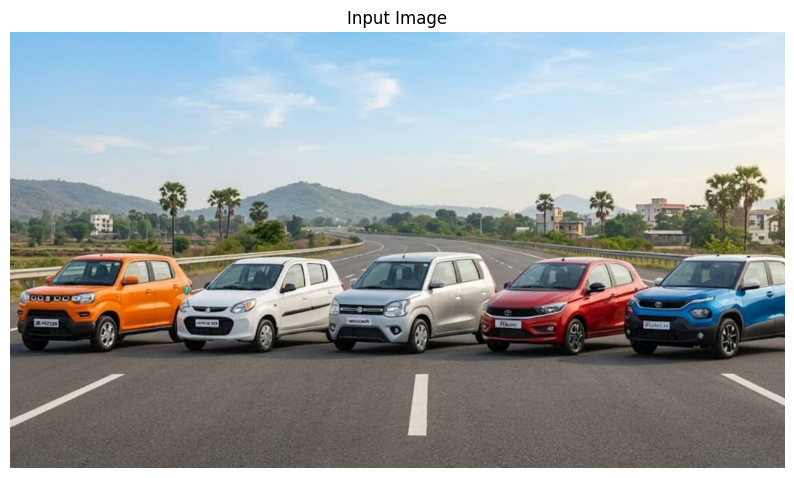

In [11]:
uploaded = files.upload()
input_name = next(iter(uploaded))

image = cv2.imdecode(np.frombuffer(uploaded[input_name], np.uint8), cv2.IMREAD_COLOR)

if image is None:
    raise ValueError("Could not read the uploaded image.")

object_name = input("Enter the object you want to outline: ").strip().lower()

print(f"✅ Loaded: {input_name}")
print(f"🎯 Requested object: {object_name}")

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Input Image")
plt.axis("off")
plt.show()

In [12]:
def find_matching_class_id(name):
    name = name.lower().strip()
    aliases = {
        "bike": "bicycle",
        "motorbike": "motorcycle",
        "tv": "tv",
        "cellphone": "cell phone",
        "mobile": "cell phone",
    }
    name = aliases.get(name, name)

    for idx, label in model.names.items():
        if label.lower() == name:
            return idx
    return None

class_id = find_matching_class_id(object_name)

result = model.predict(
    source=image,
    conf=0.25,
    verbose=False
)[0]

mask = None
confidence = None
detected_label = None

if class_id is not None and result.masks is not None and result.boxes is not None:
    for i, cls_tensor in enumerate(result.boxes.cls):
        cls = int(cls_tensor.item())
        if cls == class_id:
            conf = float(result.boxes.conf[i].item())
            candidate = result.masks.data[i].cpu().numpy()
            candidate = cv2.resize(
                candidate,
                (image.shape[1], image.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )
            # Combine all matching instances across the frame
            if mask is None:
                mask = candidate
                confidence = conf
                detected_label = model.names[cls]
            else:
                mask = np.maximum(mask, candidate)
                if conf > confidence:
                    confidence = conf

if mask is not None:
    mask = (mask > 0.5).astype(np.uint8) * 255
    print(f"✅ Detected: {detected_label}")
    print(f"📈 Max Confidence: {confidence:.2%}")
else:
    print("⚠️ Requested object was not found by the standard YOLO classes.")
    print("The project will use the structural-outline fallback below.")

✅ Detected: car
📈 Max Confidence: 86.24%


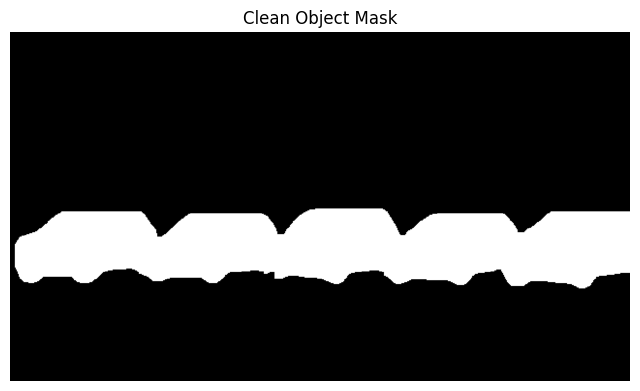

In [13]:
def clean_mask(binary_mask):
    kernel = np.ones((5, 5), np.uint8)
    cleaned = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel, iterations=1)
    return cleaned # Preserves all detected object instances

if mask is not None:
    mask = clean_mask(mask)

    plt.figure(figsize=(8, 6))
    plt.imshow(mask, cmap="gray")
    plt.title("Clean Object Mask")
    plt.axis("off")
    plt.show()

In [14]:
def to_gray_blurred(img, blur_ksize=5):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.GaussianBlur(gray, (blur_ksize, blur_ksize), 0)

def auto_canny(gray, sigma=0.33):
    v = float(np.median(gray))
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    return cv2.Canny(gray, lower, upper)

def detect_lines_hough(edges, min_line_length=40, max_line_gap=10, threshold=50):
    lines = cv2.HoughLinesP(
        edges, 1, np.pi / 180, threshold=threshold,
        minLineLength=min_line_length, maxLineGap=max_line_gap
    )
    if lines is None:
        return []
    # Reshape safely handles 3D array inputs and maps to standard python ints
    return [tuple(map(int, line)) for line in lines.reshape(-1, 4)]

def detect_harris_corners(gray, block_size=2, ksize=3, k=0.04, thresh_ratio=0.01):
    response = cv2.cornerHarris(np.float32(gray), block_size, ksize, k)
    response = cv2.dilate(response, None)
    threshold = thresh_ratio * response.max()
    ys, xs = np.where(response > threshold)
    return list(zip(xs.tolist(), ys.tolist())), response

def detect_hessian(gray, sobel_ksize=3, thresh_ratio=0.01, nms_ksize=9):
    g = np.float32(gray)
    Ix = cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=sobel_ksize)
    Iy = cv2.Sobel(g, cv2.CV_32F, 0, 1, ksize=sobel_ksize)
    Ixx = cv2.Sobel(Ix, cv2.CV_32F, 1, 0, ksize=sobel_ksize)
    Iyy = cv2.Sobel(Iy, cv2.CV_32F, 0, 1, ksize=sobel_ksize)
    Ixy = cv2.Sobel(Ix, cv2.CV_32F, 0, 1, ksize=sobel_ksize)

    det = Ixx * Iyy - Ixy ** 2
    local_max = cv2.dilate(det, np.ones((nms_ksize, nms_ksize), np.uint8))
    threshold = thresh_ratio * max(float(det.max()), 1e-6)
    keep = (det == local_max) & (det > threshold)
    ys, xs = np.where(keep)
    return list(zip(xs.tolist(), ys.tolist())), det

gray = to_gray_blurred(image)
edges = auto_canny(gray)
lines = detect_lines_hough(edges)
harris_points, harris_response = detect_harris_corners(gray)
hessian_points, hessian_response = detect_hessian(gray)

print("Canny edge pixels:", int(np.count_nonzero(edges)))
print("Hough line segments:", len(lines))
print("Harris corners:", len(harris_points))
print("Hessian points:", len(hessian_points))

Canny edge pixels: 31251
Hough line segments: 156
Harris corners: 21723
Hessian points: 2358


In [15]:
def structural_fallback(img):
    gray = to_gray_blurred(img, 5)
    e = auto_canny(gray)
    kernel = np.ones((5, 5), np.uint8)
    e = cv2.morphologyEx(e, cv2.MORPH_CLOSE, kernel, iterations=2)

    contours, _ = cv2.findContours(e, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    keep = []
    total_area = img.shape[0] * img.shape[1]
    for c in contours:
        area = cv2.contourArea(c)
        if area >= total_area * 0.003:
            keep.append(c)
        if len(keep) >= 8:
            break

    return keep

if mask is not None:
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = [c for c in contours if cv2.contourArea(c) > 20]
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    mode = "AI segmentation"
else:
    contours = structural_fallback(image)
    mode = "Structural fallback"

final_outline = image.copy()
cv2.drawContours(final_outline, contours, -1, (0, 255, 0), 4)

# Create black/white silhouette
silhouette = np.zeros(image.shape[:2], dtype=np.uint8)
if contours:
    cv2.drawContours(silhouette, contours, -1, 255, -1)

# Sketch-style outline
sketch = np.full_like(image, 255)
if contours:
    cv2.drawContours(sketch, contours, -1, (0, 0, 0), 2)

print("Processing mode:", mode)
print("Contours used:", len(contours))

Processing mode: AI segmentation
Contours used: 1


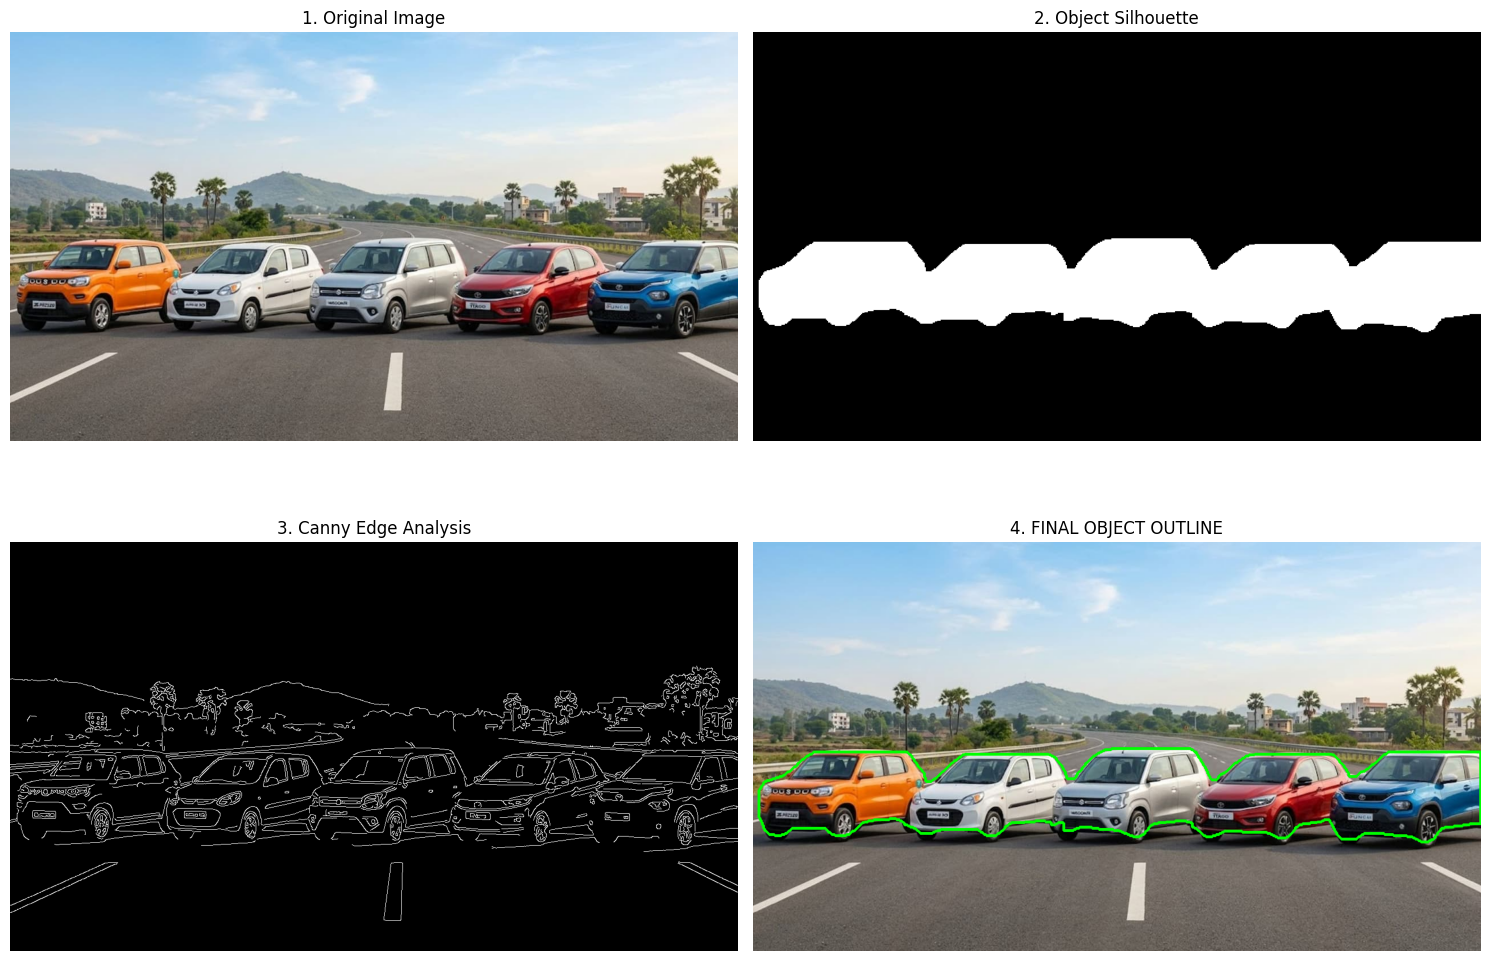

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

axes[0, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("1. Original Image")

axes[0, 1].imshow(silhouette, cmap="gray")
axes[0, 1].set_title("2. Object Silhouette")

axes[1, 0].imshow(edges, cmap="gray")
axes[1, 0].set_title("3. Canny Edge Analysis")

axes[1, 1].imshow(cv2.cvtColor(final_outline, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title("4. FINAL OBJECT OUTLINE")

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

Dropdown(description='Style:', options=('Green Outline', 'Black Sketch', 'White Silhouette', 'Original + Outli…

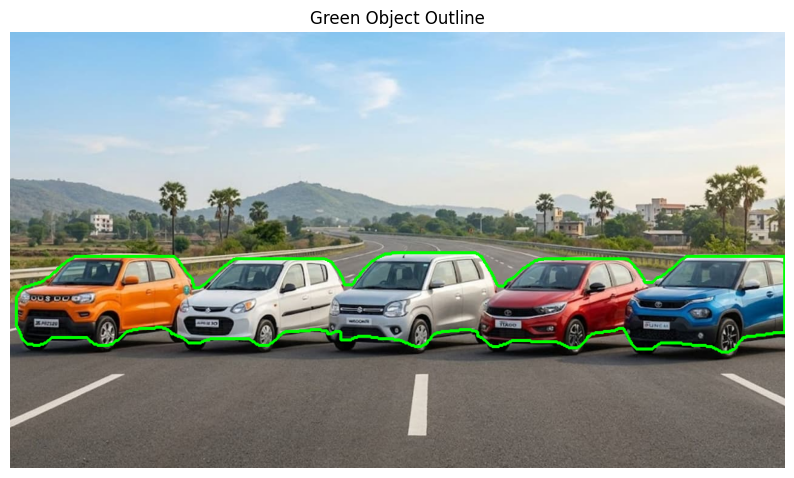

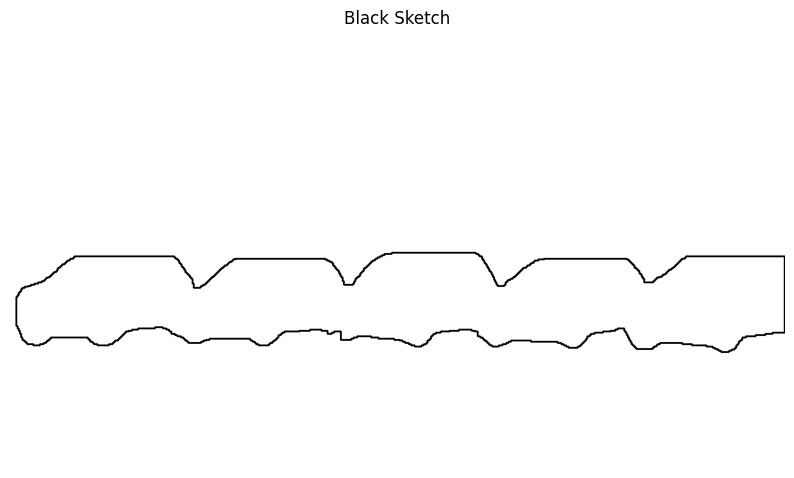

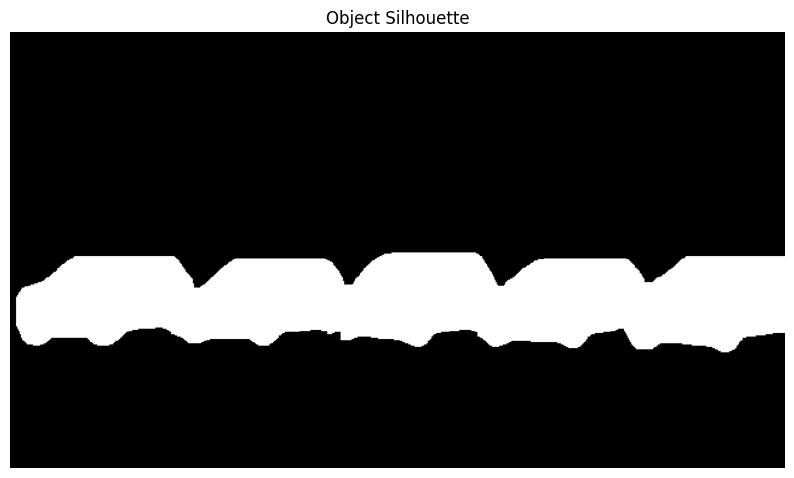

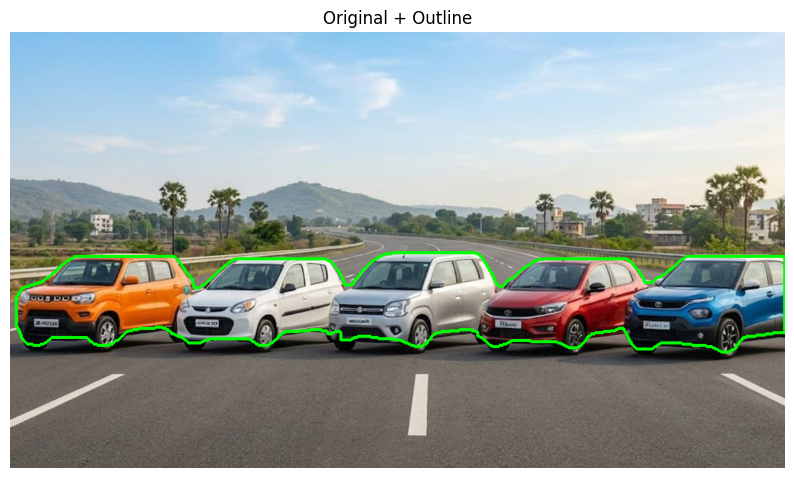

In [17]:
styles = widgets.Dropdown(
    options=["Green Outline", "Black Sketch", "White Silhouette", "Original + Outline"],
    value="Green Outline",
    description="Style:"
)
display(styles)

def show_style(change=None):
    if change is not None and change["name"] != "value":
        return

    choice = styles.value

    if choice == "Green Outline":
        result_img = final_outline
        title = "Green Object Outline"
    elif choice == "Black Sketch":
        result_img = sketch
        title = "Black Sketch"
    elif choice == "White Silhouette":
        result_img = cv2.cvtColor(silhouette, cv2.COLOR_GRAY2RGB)
        title = "Object Silhouette"
    else:
        result_img = final_outline
        title = "Original + Outline"

    plt.figure(figsize=(10, 7))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB) if len(result_img.shape) == 3 else result_img, cmap=None if len(result_img.shape) == 3 else "gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

styles.observe(show_style)
show_style()

In [18]:
image_area = image.shape[0] * image.shape[1]
object_area = int(cv2.countNonZero(silhouette))
boundary_pixels = int(cv2.countNonZero(cv2.Canny(silhouette, 50, 150)))
object_ratio = (object_area / image_area * 100) if image_area else 0

print("╔══════════════════════════════════════╗")
print("║       OBJECT OUTLINE ANALYSIS        ║")
print("╠══════════════════════════════════════╣")
print(f"║ Image size       : {image.shape[1]} × {image.shape[0]}")
print(f"║ Processing mode  : {mode}")
print(f"║ Object area      : {object_area:,} pixels")
print(f"║ Object coverage  : {object_ratio:.2f}%")
print(f"║ Boundary pixels  : {boundary_pixels:,}")
print(f"║ Hough lines      : {len(lines)}")
print(f"║ Harris corners   : {len(harris_points)}")
print(f"║ Hessian points   : {len(hessian_points)}")
print("╚══════════════════════════════════════╝")

╔══════════════════════════════════════╗
║       OBJECT OUTLINE ANALYSIS        ║
╠══════════════════════════════════════╣
║ Image size       : 1280 × 720
║ Processing mode  : AI segmentation
║ Object area      : 161,082 pixels
║ Object coverage  : 17.48%
║ Boundary pixels  : 2,735
║ Hough lines      : 156
║ Harris corners   : 21723
║ Hessian points   : 2358
╚══════════════════════════════════════╝


In [ ]:
out_dir = "Object_Outline_Results"
os.makedirs(out_dir, exist_ok=True)

cv2.imwrite(f"{out_dir}/01_original.png", image)
cv2.imwrite(f"{out_dir}/02_object_silhouette.png", silhouette)
cv2.imwrite(f"{out_dir}/03_canny_edges.png", edges)
cv2.imwrite(f"{out_dir}/04_final_object_outline.png", final_outline)
cv2.imwrite(f"{out_dir}/05_black_sketch.png", sketch)

# Hough visualization
hough_vis = image.copy()
for x1, y1, x2, y2 in lines:
    cv2.line(hough_vis, (x1, y1), (x2, y2), (0, 255, 255), 2)
cv2.imwrite(f"{out_dir}/06_hough_lines.png", hough_vis)

# Harris visualization
harris_vis = image.copy()
for x, y in harris_points:
    cv2.circle(harris_vis, (x, y), 3, (0, 0, 255), -1)
cv2.imwrite(f"{out_dir}/07_harris_corners.png", harris_vis)

# Hessian visualization
hessian_vis = image.copy()
for x, y in hessian_points:
    cv2.circle(hessian_vis, (x, y), 3, (255, 0, 255), -1)
cv2.imwrite(f"{out_dir}/08_hessian_points.png", hessian_vis)

zip_path = "Object_Outline_Results.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(out_dir):
        zf.write(os.path.join(out_dir, fname), arcname=fname)

print(f"✅ Saved results to {out_dir}/")
files.download(zip_path)